# Text classification with Pytorch

The goal of this lab are to explore the various way to represent textual data by applying them to a relatively small classification dataset - **20NewsGroup** - and evaluate how they perform on the classification task. 
1. Using what we have previously seen, pre-process the data: clean it, obtain an appropriate vocabulary.
2. Obtain representations: any that will allow us to obtain a vector representation of each document is appropriate.
    - Symbolic: **BoW, TF-IDF**
    - Dense document representations: via **Topic Modeling: LSA, LDA**
    - Dense word representations: **SVD-reduced PPMI, Word2vec, GloVe**
        - For these, you will need to implement a **function aggregating word representations into document representations**
3. Perform classification: we can make things simple and only use a **logistic regression**
4. Learn how to use Pytorch for treating textual data, and implement **neural** classification models with Pytorch.

Besides ```torch```, we will use ```gensim``` to obain word embeddings, and ```scikit-learn``` for simple classification models.  

In [1]:
import os
import os.path as op
import re 
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

## I - Simple classifier on top of dense representations 

### I.1 Dataset

We're going to work with the **20NewsGroup** data. This dataset is available in ```scikit-learn```, you can find all relevant information in the [documentation](https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html).

In [2]:
from sklearn.datasets import fetch_20newsgroups

In [3]:
# Import training data
ng_train = fetch_20newsgroups(subset='train',
                              remove=('headers', 'footers', 'quotes')
                              )

In [4]:
# Let's look at what is in this object
pprint(dir(ng_train))

['DESCR', 'data', 'filenames', 'target', 'target_names']


In [5]:
# Let's look at the categories
pprint(ng_train.target_names)

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']


In [6]:
# .. and the data itself
pprint(ng_train.data[0])
print("Target: ", ng_train.target_names[ng_train.target[0]])

('I was wondering if anyone out there could enlighten me on this car I saw\n'
 'the other day. It was a 2-door sports car, looked to be from the late 60s/\n'
 'early 70s. It was called a Bricklin. The doors were really small. In '
 'addition,\n'
 'the front bumper was separate from the rest of the body. This is \n'
 'all I know. If anyone can tellme a model name, engine specs, years\n'
 'of production, where this car is made, history, or whatever info you\n'
 'have on this funky looking car, please e-mail.')
Target:  rec.autos


The dataset can be rather difficult as it is; especially, some categories are very close to each other. We can simplify the task by using the higher-level categorisation of the newsgroups, thanks to the following function:

In [7]:
def aggregate_labels(label):
    # comp
    if label in [1,2,3,4,5]:
        new_label = 0
    # rec
    if label in [7,8,9,10]:
        new_label = 1
    # sci
    if label in [11,12,13,14]:
        new_label = 2
    # misc 
    if label in [6]:
        new_label = 3
    # pol
    if label in [16,17,18]:
        new_label = 4
    # rel
    if label in [0,15,19]:
        new_label = 5
    return new_label

We will first need to apply some pre-processing. We will here use our own tokenizer, imported from ```nltk```: ```word_tokenize```; and the processing you estimate appropriate. Careful, the data is not always clean and the messages are sometimes short: hence, applying pre-processing and tokenization can easily return an empty list of words. **Be careful to remove documents that are empty !**
<div class='alert alert-block alert-info'>
            Code:</div>

In [8]:
import nltk
nltk.data.path.append(os.path.expanduser('~/.local/share/nltk_data'))
# The first time you import this tokenizer, you need to download some data
from nltk import word_tokenize

In [9]:
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize

def get_wordnet_pos(treebank_tag):
    """Convert TreeBank POS tags to WordNet POS tags for lemmatization."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)

    stop_words = stopwords.words('english')
    tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    pos_tags = pos_tag(tokens)  # Part-of-speech tagging

    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags]
    return tokens

In [10]:
# Pre-processing 
ng_train_text_full = [preprocess(txt) for txt in ng_train.data]
print(len(ng_train_text_full))
ng_train_text = [txt for txt in ng_train_text_full if txt]
print(len(ng_train_text))
ng_train_labels = [aggregate_labels(ng_train.target[i]) for i in range(len(ng_train.target)) if ng_train_text_full[i]]
print(len(ng_train_labels))

11314
11000
11000


In [11]:
print(" ".join(ng_train_text[0]))

wonder anyone could enlighten car saw day door sport car look late early call bricklin door really small addition front bumper separate rest body know anyone tellme model name engine spec year production car make history whatever info funky look car please email


In [12]:
ng_test = fetch_20newsgroups(subset='test',
                             remove=('headers', 'footers', 'quotes')
                            )

ng_test_text_full = [preprocess(txt) for txt in ng_test.data]
ng_test_text = [txt for txt in ng_test_text_full if txt]
ng_test_labels = [aggregate_labels(ng_test.target[i]) for i in range(len(ng_test.target)) if ng_test_text_full[i]]

### I.2 Get a vocabulary.

Now that the data is cleaned, the first step we will follow is to pick a common vocabulary that we will use for every model we create in this lab. **Use the code of the previous lab to create a vocabulary.** As in the previous lab, we will have to be able to control its size, either by indicating a maximum number of words, or a minimum number of occurrences to take the words into account. Again, we add, at the end, an "unknown" word that will replace all the words that do not appear in our "limited" vocabulary. 
<div class='alert alert-block alert-info'>
            Code:</div>

In [13]:
from collections import defaultdict


def vocabulary(corpus, voc_threshold=0, count_threshold=0):
    """    
    Function using word counts to build a vocabulary - can be improved with a second parameter for 
    setting a frequency threshold
    Params:
        corpus (list of list of strings): corpus of sentences
        voc_threshold (int): maximum size of the vocabulary (0 means no limit !)
    Returns:
        vocabulary (dictionary): keys: list of distinct words across the corpus
                                 values: indexes corresponding to each word sorted by frequency 
        word_counts (dictionary): keys: list of distinct words across the corpus  
                                  values: their counts in the corpus  
    """  
    word_counts = defaultdict(int)
    for sent in corpus:
        for word in sent:
            word_counts[word.lower()] += 1
            
    filtered_word_counts = {word: count for word, count in word_counts.items() if count > count_threshold} # Filter according to count_threhshold        
    sorted_words = sorted(list(filtered_word_counts.keys()), reverse=True, key=filtered_word_counts.get) # Extract the words according to frequency
    filtered_words = sorted_words[:voc_threshold] # Remove the words above voc-threshold
    words = filtered_words + ["unk"] # Add UNK
    vocabulary = {w: i for i, w in enumerate(words)} # Create vocabulary from "words"
    return vocabulary, {word: filtered_word_counts.get(word, 0) for word in vocabulary}


<div class='alert alert-block alert-warning'>
            Question:</div>
            
What do you think is the **appropriate vocabulary size here** ? Would any further pre-processing make sense ? Motivate your answer. 

**Answer**: To train a model, it is reasonable to use the vocabulary based on the training data, so the vocabulary size would be the number of words in the training texts. However, to achieve a good performance standard, we might want to reduce the vocabulary size. To this end, we could, for instance, compute the TF-IDF of each word in the vocabulary and only keep those whose score is high enough.
Moreover, we could lower all characters to work only with lower case.

Before creating the vocabulary, put aside some training data for a **validation set** ! 

In [14]:
from sklearn.model_selection import train_test_split
train_texts_splt, val_texts, train_labels_splt, val_labels = train_test_split(ng_train_text, ng_train_labels, test_size=.2)

In [15]:
# Get the vocabulary from 'train_texts_splt'
voc, word_counts = vocabulary(train_texts_splt, voc_threshold=16_000)

### I.3 - Symbolic text representations

We can use the ```CountVectorizer``` class from scikit-learn to obtain the first set of representations:
- Use the appropriate argument to get your own vocabulary
- Fit the vectorizer on your training data, transform your test data
- Create a ```LogisticRegression``` model and train it with these representations. Display the confusion matrix using functions from ```sklearn.metrics``` 

Then, re-execute the same pipeline with the ```TfidfVectorizer```.

<div class='alert alert-block alert-info'>
            Code:</div>

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [17]:
pipeline_base = Pipeline([
    ('vect', CountVectorizer(vocabulary=voc)),
    ('clf', LogisticRegression()),
])

pipeline_base.fit([str(txt) for txt in train_texts_splt], train_labels_splt)

val_pred = pipeline_base.predict([str(txt) for txt in val_texts])
print(classification_report(val_labels, val_pred))
confusion_matrix(val_labels, val_pred)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       551
           1       0.78      0.87      0.82       465
           2       0.76      0.75      0.76       439
           3       0.73      0.63      0.68       104
           4       0.85      0.73      0.78       340
           5       0.86      0.75      0.80       301

    accuracy                           0.81      2200
   macro avg       0.80      0.77      0.78      2200
weighted avg       0.81      0.81      0.80      2200



array([[499,  16,  26,   8,   1,   1],
       [ 16, 404,  26,  10,   4,   5],
       [ 45,  32, 329,   3,  16,  14],
       [ 15,   9,   9,  66,   3,   2],
       [ 16,  35,  23,   2, 248,  16],
       [ 10,  23,  19,   2,  20, 227]])

In [18]:
pipeline_base = Pipeline([
    ('vect', TfidfVectorizer(vocabulary=voc)),
    ('clf', LogisticRegression()),
])

pipeline_base.fit([str(txt) for txt in train_texts_splt], train_labels_splt)

val_pred = pipeline_base.predict([str(txt) for txt in val_texts])
print(classification_report(val_labels, val_pred))
confusion_matrix(val_labels, val_pred)

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       551
           1       0.81      0.88      0.84       465
           2       0.77      0.79      0.78       439
           3       0.82      0.54      0.65       104
           4       0.84      0.75      0.79       340
           5       0.91      0.78      0.84       301

    accuracy                           0.82      2200
   macro avg       0.83      0.78      0.80      2200
weighted avg       0.83      0.82      0.82      2200



array([[512,   8,  22,   5,   2,   2],
       [ 14, 410,  23,   7,   7,   4],
       [ 43,  22, 348,   0,  18,   8],
       [ 21,  13,  12,  56,   1,   1],
       [ 13,  35,  28,   0, 255,   9],
       [  8,  20,  18,   0,  21, 234]])

### I.4 - Dense Representations from Topic Modeling

Now, the goal is to re-use the bag-of-words representations we obtained earlier - but reduce their dimension through a **topic model**. Note that this allows to obtain reduced **document representations**, which we can again use directly to perform classification.
- Do this with two models: ```TruncatedSVD``` and ```LatentDirichletAllocation```
- Pick $300$ as the dimensionality of the latent representation (*i.e*, the number of topics)

<div class='alert alert-block alert-info'>
            Code:</div>

In [19]:
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

In [20]:
pipeline_base = Pipeline([
    ('vect', TfidfVectorizer(vocabulary=voc)),
    ('svd', TruncatedSVD(n_components=300)),
    ('clf', LogisticRegression()),
])

pipeline_base.fit([str(txt) for txt in train_texts_splt], train_labels_splt)

val_pred = pipeline_base.predict([str(txt) for txt in val_texts])
print(classification_report(val_labels, val_pred))
confusion_matrix(val_labels, val_pred)

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       551
           1       0.76      0.85      0.80       465
           2       0.72      0.75      0.74       439
           3       0.84      0.51      0.63       104
           4       0.82      0.70      0.76       340
           5       0.88      0.74      0.80       301

    accuracy                           0.79      2200
   macro avg       0.81      0.74      0.77      2200
weighted avg       0.80      0.79      0.79      2200



array([[502,  18,  25,   4,   0,   2],
       [ 18, 396,  30,   6,   9,   6],
       [ 49,  28, 329,   0,  22,  11],
       [ 21,  17,  11,  53,   2,   0],
       [ 13,  39,  37,   0, 239,  12],
       [ 11,  25,  23,   0,  20, 222]])

In [21]:
pipeline_base = Pipeline([
    ('vect', TfidfVectorizer(vocabulary=voc)),
    ('svd', LatentDirichletAllocation(n_components=300)),
    ('clf', LogisticRegression()),
])

pipeline_base.fit([str(txt) for txt in train_texts_splt], train_labels_splt)

val_pred = pipeline_base.predict([str(txt) for txt in val_texts])
print(classification_report(val_labels, val_pred))
print(confusion_matrix(val_labels, val_pred))

              precision    recall  f1-score   support

           0       0.64      0.78      0.70       551
           1       0.65      0.62      0.63       465
           2       0.53      0.56      0.54       439
           3       0.79      0.25      0.38       104
           4       0.64      0.56      0.60       340
           5       0.69      0.64      0.66       301

    accuracy                           0.63      2200
   macro avg       0.65      0.57      0.59      2200
weighted avg       0.63      0.63      0.62      2200

[[432  36  66   2   5  10]
 [ 73 289  59   2  22  20]
 [ 90  50 247   2  35  15]
 [ 40  13  19  26   4   2]
 [ 26  37  46   1 189  41]
 [ 15  22  32   0  39 193]]


### I.5 - Dense Count-based Representations

The following function allows to obtain very large-dimensional vectors for **words**. We will now follow a different procedure:
- Use ```TruncatedSVD```to obtain **word embeddings** of dimension $300$ from the output of the ```co_occurence_matrix```function, to which you can apply any intermediate transformation you see fit. 
- Complete the following ```sentence_representations``` matrix, which will allow you to obtain **document representations** from **word embeddings**. 
- Put the pipeline together and obtain document representations for both training and testing data, using word embeddings you got from the *training data co-occurence matrix*.
- Apply the same classification model as before, and display the results.

<div class='alert alert-block alert-info'>
            Code:</div>

In [22]:
def co_occurence_matrix(corpus, vocabulary, window=0, distance_weighting=False):
    """
    Params:
        corpus (list of list of strings): corpus of sentences
        vocabulary (dictionary): words to use in the matrix
        window (int): size of the context window; when 0, the context is the whole sentence
        distance_weighting (bool): indicates if we use a weight depending on the distance between words for co-oc counts
    Returns:
        matrix (array of size (len(vocabulary), len(vocabulary))): the co-oc matrix, using the same ordering as the vocabulary given in input    
    """ 
    l = len(vocabulary)
    M = np.zeros((l,l))
    for sent in corpus:
        # Obtain the indexes of the words in the sentence from the vocabulary 
        sent_idx = [vocabulary[word] if word in vocabulary else vocabulary["unk"] for word in sent]
        # Avoid one-word sentences - can create issues in normalization:
        if len(sent_idx) == 1:
                sent_idx.append(len(vocabulary)-1)
        # Go through the indexes and add 1 / dist(i,j) to M[i,j] if words of index i and j appear in the same window
        for i, idx in enumerate(sent_idx):
            # If we consider a limited context:
            if window > 0:
                # Create a list containing the indexes that are on the left of the current index 'idx_i'
                l_ctx_idx = sent_idx[i - window:i]
            # If the context is the entire document:
            else:
                # The list containing the left context is easier to create
                l_ctx_idx = sent_idx[:i]
            # Go through the list and update M[i,j]:        
            for j, ctx_idx in enumerate(l_ctx_idx):
                if distance_weighting:
                    weight = 1 / (len(l_ctx_idx) - j)
                else:
                    weight = 1
                M[idx, ctx_idx] += weight * 1.0
                M[ctx_idx, idx] += weight * 1.0
    return M

In [23]:
# Obtain the co-occurence matrix, transform it as needed, reduce its dimension
cooc_matrix = co_occurence_matrix(train_texts_splt, voc, window=3, distance_weighting=True)

In [24]:
cooc_matrix = TruncatedSVD(n_components=300).fit_transform(cooc_matrix)

In [25]:
cooc_matrix.shape

(16001, 300)

We will now use these representations for classification.
The basic model will be constructed in two steps:
- A function to obtain vector representations of criticism, from text, vocabulary, and vector representations of words. Such a function (to be completed below) will associate to each word of a review its embeddings, and create the representation for the whole sentence by summing these embeddings.
- A classifier will take these representations as input and make a prediction. To achieve this, we can first use logistic regression ```LogisticRegression``` from ```scikit-learn``` 

<div class='alert alert-block alert-info'>
            Code:</div>

In [26]:
def sentence_representations(texts, vocabulary, embeddings, np_func=np.mean):
    """
    Represent the sentences as a combination of the vector of its words.
    Parameters
    ----------
    texts : a list of sentences   
    vocabulary : dict
        From words to indexes of vector.
    embeddings : Matrix containing word representations
    np_func : function (default: np.sum)
        A numpy matrix operation that can be applied columnwise, 
        like `np.mean`, `np.sum`, or `np.prod`. 
    Returns
    -------
    np.array, dimension `(len(texts), embeddings.shape[1])`            
    """
    representations = np.zeros((len(texts), embeddings.shape[1]))

    for i, text in enumerate(texts):
        sent_repr = np.zeros((len(text), embeddings.shape[1]))
        
        for j, word in enumerate(text):
            idx = vocabulary[word] if word in vocabulary else vocabulary["unk"]
            sent_repr[j] = embeddings[idx] if idx < embeddings.shape[0] else vocabulary["unk"]
            
        representations[i] = np_func(sent_repr, axis=0)

    return representations

In [27]:
# Obtain document representations, apply the classifier
sent_repr = sentence_representations(train_texts_splt, voc, cooc_matrix)

In [28]:
lr = LogisticRegression(max_iter=10_000)
lr.fit(sent_repr, train_labels_splt)

val_pred = lr.predict(sentence_representations(val_texts, voc, cooc_matrix))
print(classification_report(val_labels, val_pred))
print(confusion_matrix(val_labels, val_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       551
           1       0.75      0.78      0.77       465
           2       0.65      0.73      0.69       439
           3       0.66      0.50      0.57       104
           4       0.73      0.69      0.71       340
           5       0.76      0.70      0.73       301

    accuracy                           0.75      2200
   macro avg       0.73      0.71      0.72      2200
weighted avg       0.75      0.75      0.75      2200

[[457  20  53  12   5   4]
 [ 19 365  43   8  15  15]
 [ 34  36 321   4  31  13]
 [ 17  16  12  52   5   2]
 [ 13  22  35   2 236  32]
 [  4  26  27   1  31 212]]


/Users/vicentin/.pyenv/versions/3.12.9/envs/telecom-paris/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### I.6 - Dense Prediction-based Representations

We will now use two types of word embeddings: 
1. From ```Word2Vec```: which we will train ourselves
2. From ```GloVe```: which we will import 

We will use the ```gensim``` library for its implementation of word2vec in python. Since we want to keep the same vocabulary as before: we'll first create the class, then get the vocabulary we generated above. 

#### Glove

In [29]:
import gensim.downloader as api
loaded_glove_model = api.load("glove-wiki-gigaword-300")

We can extract the embedding matrix this way, and check its size:

In [30]:
loaded_glove_embeddings = loaded_glove_model.vectors
print(loaded_glove_embeddings.shape)

(400000, 300)


We can see that there are $400,000$ words represented, and that the embeddings are of size $300$. We define a function that returns, from the loaded model, the vocabulary and the embedding matrix according to the structures we used before. We add, here again, an unknown word "UNK" in case there are words in our data that are not part of the $400,000$ words represented here. 

In [31]:
def get_glove_voc_and_embeddings(glove_model):
    voc = {word : index for word, index in enumerate(glove_model.index_to_key)}
    voc['UNK'] = len(voc)
    embeddings = glove_model.vectors
    return voc, embeddings

In [32]:
loaded_glove_voc, loaded_glove_embeddings = get_glove_voc_and_embeddings(loaded_glove_model)

To be able to merge these $400.000$ words with those that are in our vocabulary, we can create a specific function that will extract the representations of the words that are in our vocabulary and return a matrix of the appropriate size:

In [33]:
def get_glove_adapted_embeddings(glove_model, input_voc):
    keys = {i: glove_model.key_to_index.get(w, None) for w, i in input_voc.items()}
    index_dict = {i: key for i, key in keys.items() if key is not None}
    embeddings = np.zeros((len(input_voc),glove_model.vectors.shape[1]))
    for i, ind in index_dict.items():
        embeddings[i] = glove_model.vectors[ind]
    return embeddings

This function takes as input the model loaded using the Gensim API, as well as a vocabulary we created ourselves, and returns the embedding matrix from the loaded model, for the words in our vocabulary and in the right order.


In [34]:
GloveEmbeddings = get_glove_adapted_embeddings(loaded_glove_model, voc) # Use your vocabulary

In [35]:
print(GloveEmbeddings)

[[-0.10515     0.13406999  0.13839    ... -0.41949001  0.089402
   0.17569   ]
 [-0.36756     0.39500001 -0.27034    ... -0.37252    -0.3899
   0.031491  ]
 [-0.32229    -0.28106001  0.51416999 ... -0.090831    0.43952
   0.51388001]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.25172001  0.27164    -0.14134    ... -0.15162    -0.15024
   0.14139999]
 [ 0.30070999 -0.46867001 -0.20616999 ...  0.49267    -0.11276
  -0.27774999]]


In [36]:
print(GloveEmbeddings.shape)

(16001, 300)


#### Word2Vec

We will use the ```gensim``` library for its implementation of word2vec in python. We'll have to make a specific use of it, since we want to keep the same vocabulary as before: we'll first create the class, then get the vocabulary we generated above. 

In [37]:
from gensim.models import Word2Vec

model = Word2Vec(vector_size=300,
                 window=5,
                 null_word=len(word_counts), # Use word counts
                 epochs=30,
                 min_count=1)

model.build_vocab_from_freq(word_counts) # Use word counts

The model takes as input a **list of list of words**: you need to tokenize the data beforehand. 
In this case, you also need to indicate to the model the number of examples it should train with.
<div class='alert alert-block alert-info'>
            Code:</div>

In [38]:
ex = len(train_texts_splt)

In [39]:
model.train(train_texts_splt, total_examples=ex, epochs=30, report_delay=1)

(24019559, 26826960)

In [40]:
W2VEmbeddings = model.wv.vectors
print(W2VEmbeddings.shape)

(16001, 300)


In [41]:
# Re-train a Logistic regression classifier with those representations
lr = LogisticRegression(max_iter=10_000)
lr.fit(sentence_representations(train_texts_splt, voc, W2VEmbeddings), train_labels_splt)

val_pred = lr.predict(sentence_representations(val_texts, voc, W2VEmbeddings))
print(classification_report(val_labels, val_pred))
print(confusion_matrix(val_labels, val_pred))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       551
           1       0.68      0.73      0.71       465
           2       0.60      0.62      0.61       439
           3       0.68      0.51      0.58       104
           4       0.68      0.62      0.65       340
           5       0.72      0.68      0.70       301

    accuracy                           0.69      2200
   macro avg       0.69      0.66      0.67      2200
weighted avg       0.69      0.69      0.69      2200

[[438  29  49  10  13  12]
 [ 29 340  43  10  26  17]
 [ 65  44 273   3  31  23]
 [ 15  19  11  53   4   2]
 [ 15  40  45   1 212  27]
 [  7  27  32   1  28 206]]


In [42]:
# Re-train a Logistic regression classifier with those representations
lr = LogisticRegression(max_iter=10_000)
lr.fit(sentence_representations(train_texts_splt, voc, GloveEmbeddings), train_labels_splt)

val_pred = lr.predict(sentence_representations(val_texts, voc, GloveEmbeddings))
print(classification_report(val_labels, val_pred))
print(confusion_matrix(val_labels, val_pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       551
           1       0.82      0.87      0.85       465
           2       0.71      0.72      0.72       439
           3       0.74      0.57      0.64       104
           4       0.78      0.74      0.76       340
           5       0.83      0.79      0.81       301

    accuracy                           0.80      2200
   macro avg       0.79      0.76      0.77      2200
weighted avg       0.79      0.80      0.79      2200

[[478  17  37  10   5   4]
 [  9 404  23   7  13   9]
 [ 52  24 318   4  28  13]
 [ 18  16   8  59   1   2]
 [ 10  18  38   0 252  22]
 [  5  11  22   0  24 239]]


<div class='alert alert-block alert-warning'>
            Question:</div>

- Why can we expect that the results obtained with embeddings extracted from representations pre-trained with Gl0ve are much better than word2vec ? What would be a 'fair' way to compare Gl0ve with word2vec ?

**Answer**: GloVe usually works better than Word2Vec because it learns from the whole dataset, not just nearby words. To compare them fairly, we should use the same settings (like size, model, and data). That way, we know which one really performs better.

<div class='alert alert-block alert-warning'>
            Question:</div>

- Try to have an high-level analysis of the results. Which representation works the best ? Did the confusion matrix give you any insight ? 

**Answer**: The best representation was the TfIdf vectorization with Logistic Regression, yielding a 82% accuracy on the validation set. The confusion matrix can help into the qualitative insight of the classification performance based on how concentrated the values are along the diagonal. A perfect classifier would produce a matrix with all non-zero entries aligned on the diagonal.

# II - Text classification with Pytorch

The goal of this second part of the lab is double: an introduction to using Pytorch for treating textual data, and implementing neural classification models that we can apply to our data - and then compare it to the models implemented previously. 

In [43]:
import torch
import torch.nn as nn

### II.1 A (very small) introduction to pytorch

Pytorch Tensors are very similar to Numpy arrays, with the added benefit of being usable on GPU. For a short tutorial on various methods to create tensors of particular types, see [this link](https://pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#sphx-glr-beginner-blitz-tensor-tutorial-py).
The important things to note are that Tensors can be created empty, from lists, and it is very easy to convert a numpy array into a pytorch tensor, and inversely.

In [44]:
a = torch.LongTensor(5)
b = torch.LongTensor([5])

print(a)
print(b)

tensor([0, 0, 0, 0, 0])
tensor([5])


In [45]:
a = torch.FloatTensor([2])
b = torch.FloatTensor([3])

print(a + b)

tensor([5.])


The main interest in us using Pytorch is the ```autograd``` package. ```torch.Tensor```objects have an attribute ```.requires_grad```; if set as True, it starts to track all operations on it. When you finish your computation, can call ```.backward()``` and all the gradients are computed automatically (and stored in the ```.grad``` attribute).

One way to easily cut a tensor from the computational once it is not needed anymore is to use ```.detach()```.
More info on automatic differentiation in pytorch on [this link](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html#sphx-glr-beginner-blitz-autograd-tutorial-py).

In [46]:
x = torch.tensor(1., requires_grad=True)
w = torch.tensor(2., requires_grad=True)
b = torch.tensor(3., requires_grad=True)

# Build a computational graph.
y = w * x + b    # y = 2 * x + 3

# Compute gradients.
y.backward()

# Print out the gradients.
print(x.grad)    # x.grad = 2 
print(w.grad)    # w.grad = 1 
print(b.grad)    # b.grad = 1 

tensor(2.)
tensor(1.)
tensor(1.)


In [47]:
x = torch.randn(10, 3)
y = torch.randn(10, 2)

# Build a fully connected layer.
linear = nn.Linear(3, 2)
for name, p in linear.named_parameters():
    print(name)
    print(p)

# Build loss function - Mean Square Error
criterion = nn.MSELoss()

# Forward pass.
pred = linear(x)

# Compute loss.
loss = criterion(pred, y)
print('Initial loss: ', loss.item())

# Backward pass.
loss.backward()

# Print out the gradients.
print ('dL/dw: ', linear.weight.grad) 
print ('dL/db: ', linear.bias.grad)

weight
Parameter containing:
tensor([[-0.2628, -0.5586, -0.4154],
        [ 0.2113, -0.0906,  0.1245]], requires_grad=True)
bias
Parameter containing:
tensor([0.4878, 0.1809], requires_grad=True)
Initial loss:  2.0429654121398926
dL/dw:  tensor([[ 0.0881,  0.0675, -0.9148],
        [ 0.3518,  0.0669, -0.3158]])
dL/db:  tensor([0.3525, 0.1851])


In [48]:
# You can perform gradient descent manually, with an in-place update ...
linear.weight.data.sub_(0.01 * linear.weight.grad.data)
linear.bias.data.sub_(0.01 * linear.bias.grad.data)

# Print out the loss after 1-step gradient descent.
pred = linear(x)
loss = criterion(pred, y)
print('Loss after one update: ', loss.item())

Loss after one update:  2.030651092529297


In [49]:
# Use the optim package to define an Optimizer that will update the weights of the model.
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)

# By default, gradients are accumulated in buffers( i.e, not overwritten) whenever .backward()
# is called. Before the backward pass, we need to use the optimizer object to zero all of the
# gradients.
optimizer.zero_grad()
loss.backward()

# Calling the step function on an Optimizer makes an update to its parameters
optimizer.step()

# Print out the loss after the second step of gradient descent.
pred = linear(x)
loss = criterion(pred, y)
print('Loss after two updates: ', loss.item())

Loss after two updates:  2.018500566482544


### II.2 Tools for data processing 

```torch.utils.data.Dataset``` is an abstract class representing a dataset. Your custom dataset should inherit ```Dataset``` and override the following methods:
- ```__len__``` so that ```len(dataset)``` returns the size of the dataset.
- ```__getitem__``` to support the indexing such that ```dataset[i]``` can be used to get the i-th sample

Here is a toy example: 

In [50]:
toy_corpus = ['I walked down down the boulevard',
              'I walked down the avenue',
              'I ran down the boulevard',
              'I walk down the city',
              'I walk down the the avenue']

toy_categories = [0, 0, 1, 0, 0]

In [51]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    # A pytorch dataset class for holding data for a text classification task.
    def __init__(self, data, categories):
        # Upon creating the Dataset object, store the data in an attribute
        # Split the text data and labels from each other
        self.X, self.Y = [], []
        for x, y in zip(data, categories):
            # We will propably need to preprocess the data - have it done in a separate method
            # We do it here because we might need corpus-wide info to do the preprocessing 
            # For example, cutting all examples to the same length
            self.X.append(self.preprocess(x))
            self.Y.append(y)
                
    # Method allowing you to preprocess data                      
    def preprocess(self, text):
        text_pp = text.lower().strip()
        return text_pp
    
    # Overriding the method __len__ so that len(CustomDatasetName) returns the number of data samples                     
    def __len__(self):
        return len(self.Y)
   
    # Overriding the method __getitem__ so that CustomDatasetName[i] returns the i-th sample of the dataset                      
    def __getitem__(self, idx):
           return self.X[idx], self.Y[idx]

In [52]:
toy_dataset = CustomDataset(toy_corpus, toy_categories)

In [53]:
print(len(toy_dataset))
for i in range(len(toy_dataset)):
    print(toy_dataset[i])

5
('i walked down down the boulevard', 0)
('i walked down the avenue', 0)
('i ran down the boulevard', 1)
('i walk down the city', 0)
('i walk down the the avenue', 0)


```torch.utils.data.DataLoader``` is what we call an iterator, which provides very useful features:
- Batching the data
- Shuffling the data
- Load the data in parallel using multiprocessing workers.
and can be created very simply from a ```Dataset```. Continuing on our simple example: 

In [54]:
toy_dataloader = DataLoader(toy_dataset, batch_size = 2, shuffle = True)

In [55]:
for e in range(3):
    print("Epoch:" + str(e))
    for x, y in toy_dataloader:
        print("Batch: " + str(x) + "; labels: " + str(y))  

Epoch:0
Batch: ('i walk down the the avenue', 'i walked down the avenue'); labels: tensor([0, 0])
Batch: ('i ran down the boulevard', 'i walked down down the boulevard'); labels: tensor([1, 0])
Batch: ('i walk down the city',); labels: tensor([0])
Epoch:1
Batch: ('i walked down the avenue', 'i walk down the city'); labels: tensor([0, 0])
Batch: ('i walked down down the boulevard', 'i ran down the boulevard'); labels: tensor([0, 1])
Batch: ('i walk down the the avenue',); labels: tensor([0])
Epoch:2
Batch: ('i walked down the avenue', 'i walked down down the boulevard'); labels: tensor([0, 0])
Batch: ('i walk down the the avenue', 'i walk down the city'); labels: tensor([0, 0])
Batch: ('i ran down the boulevard',); labels: tensor([1])


#### Data processing of a text dataset

Now, we would like to apply what we saw to our case, and **create a specific class** ```TextClassificationDataset``` **inheriting** ```Dataset``` that will:
- Create a vocabulary from the data (same as above)
- Preprocess the data using this vocabulary, adding whatever we need for our pytorch model
- Have a ```__getitem__``` method that allows us to use the class with a ```Dataloader``` to easily build batches.

In [56]:
from torch.nn import functional as F
import random

from torch.nn.utils.rnn import pad_sequence

We will now need to create a ```TextClassificationDataset``` and a ```Dataloader``` for the training data, the validation data, and the testing data.

We will implement our ```TextClassificationDataset``` class, that we will build from:
- A list of documents: ```data```
- A list of the corresponding categories: ```categories```
We will add three optional arguments:
- First, a way to input a vocabulary (so that we can re-use the training vocabulary on the validation and training ```TextClassificationDataset```). By default, the value of the argument is ```None```.
- In order to work with batches, we will need to have sequences of the same size. That can be done via **padding** but we will still need to limit the size of documents (to avoid having batches of huge sequences that are mostly empty because of one very long documents) to a ```max_length```. Let's put it to 100 by default.
- Lastly, a ```min_freq``` that indicates how many times a word must appear to be taken in the vocabulary. 

The idea behind **padding** is to transform a list of pytorch tensors (of maybe different length) into a two dimensional tensor - which we can see as a batch. The size of the first dimension is the one of the longest tensor - and other are **padded** with a chosen symbol: here, we choose 0. 

**Careful: the symbol 0 is then reserved for padding. That means the vocabulary must begin at 1 !** 

In [57]:
tensor_1 = torch.LongTensor([1, 4, 5])
tensor_2 = torch.LongTensor([2])
tensor_3 = torch.LongTensor([6, 7])

In [58]:
tensor_padded = pad_sequence([tensor_1, tensor_2, tensor_3], batch_first=True, padding_value = 0)
print(tensor_padded)

tensor([[1, 4, 5],
        [2, 0, 0],
        [6, 7, 0]])


<div class='alert alert-block alert-info'>
            Code:</div>

In [59]:
class TextClassificationDataset(Dataset):
    def __init__(self, data, categories, vocab = None, max_length = 200, voc_threshold = 10000):
        # Get all the data in a list
        self.data = data
        # Set the maximum length we will keep for the sequences
        self.max_length = max_length
        # Allow to import a vocabulary (for valid/test datasets, that will use the training vocabulary)
        if vocab is not None:
            self.word2idx, self.idx2word = vocab
        else:
            # If no vocabulary imported, build it (and reverse)
            self.word2idx, self.idx2word = self.build_vocab(self.data, voc_threshold)
        
        # We then need to tokenize the data .. 
        tokenized_data = [preprocess(str(txt)) for txt in data]
        # Transform words into lists of indexes ... (use the .get() method to redirect unknown words to the UNK token)
        indexed_data = [[self.word2idx.get(word, self.word2idx["unk"]) for word in sent] for sent in tokenized_data]
        # And transform this list of lists into a list of Pytorch LongTensors
        tensor_data = [torch.LongTensor(sent[:self.max_length]) for sent in indexed_data]
        # And the categories into a FloatTensor
        tensor_y = torch.LongTensor(categories)
        # To finally cut it when it's above the maximum length
        cut_tensor_data = tensor_data
        
        # Now, we need to use the pad_sequence function to have the whole dataset represented as one tensor,
        # containing sequences of the same length. We choose the padding_value to be 0, the we want the
        # batch dimension to be the first dimension 
        self.tensor_data = pad_sequence(cut_tensor_data, batch_first=True, padding_value=0)
        self.tensor_y = tensor_y
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # The iterator just gets one particular example with its category
        # The dataloader will take care of the shuffling and batching
        if torch.is_tensor(idx):
            idx = idx.tolist()
        return self.tensor_data[idx], self.tensor_y[idx] 
    
    def build_vocab(self, corpus, voc_threshold):
        """
        Same as in the previously: we want to output word_index, a dictionary containing words 
        and their corresponding indexes as {word : indexes} 
        But we also want the reverse, which is a dictionary {indexes: word}
        """
        # To complete
        # Careful, here we need to shift the indexes by 1 to put the padding symbol to 0
        word_counts = defaultdict(int)

        for txt in corpus:
            for word in preprocess(str(txt)):
                word_counts[word] += 1

        sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
        words = [w for w, c in sorted_words[:voc_threshold]]

        word2idx = {w: i+1 for i, w in enumerate(words)}  # +1 to leave 0 for padding
        word2idx["unk"] = len(word2idx) + 1  # UNK token

        idx2word = {i: w for w, i in word2idx.items()}
        return word2idx, idx2word
    
    def get_vocab(self):
        # A simple way to get the training vocab when building the valid/test 
        return self.word2idx, self.idx2word

In [60]:
training_dataset = TextClassificationDataset(train_texts_splt, train_labels_splt)
training_word2idx, training_idx2word = training_dataset.get_vocab()

In [61]:
valid_dataset = TextClassificationDataset(val_texts, val_labels, (training_word2idx, training_idx2word))
test_dataset = TextClassificationDataset(ng_test_text, ng_test_labels, (training_word2idx, training_idx2word))

In [62]:
training_dataloader = DataLoader(training_dataset, batch_size = 200, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size = 25)
test_dataloader = DataLoader(test_dataset, batch_size = 25)

In [63]:
print(valid_dataset[1])

(tensor([ 1669,    78,     6,  3433, 10001,  1669,   705,  4854,   940,   111,
           20,    41,  7362,   940,   111,  1565,    62,    68,   635,   133,
            6,  1312,   121,    73,  1187,   264,  2614,   722,    15,   598,
           73,    13, 10001, 10001,   316,    40,    15,   243,    26,   466,
         2920,   305, 10001, 10001,  1755,    50,    11,   408,   123,  6459,
          121,  2743,   598,    39,   319,   752, 10001,  2883,  4729,    10,
        10001,  4798,  3798,    50, 10001,  3945,    11,   127,     7,  3704,
           11,  6143,  2563,   322,  8140,   466,  1312,  1187,  1187,   109,
        10001,   618,    41,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,

In [64]:
example_batch = next(iter(training_dataloader))
print(example_batch[0].size())
print(example_batch[1].size())

torch.Size([200, 200])
torch.Size([200])


### II.3 A simple averaging model

Now, we will implement in Pytorch what we did in the previous TP: a simple averaging model. For each model we will implement, we need to create a class which inherits from ```nn.Module``` and redifine the ```__init__``` method as well as the ```forward``` method.

In [65]:
import torch.optim as optim

<div class='alert alert-block alert-info'>
            Code:</div>

In [66]:
class AveragingModel(nn.Module):
    
    def __init__(self, embedding_dim, vocabulary_size, categories_num):
        super().__init__()
        # Create an embedding object. Be careful to padding - you need to increase the vocabulary size by one !
        # Look into the arguments of the nn.Embedding class
        self.embeddings = nn.Embedding(vocabulary_size + 1, embedding_dim, padding_idx=0)
        # Create a linear layer that will transform the mean of the embeddings into classification scores
        self.linear = nn.Linear(embedding_dim, categories_num)
        
    def forward(self, inputs):
        # Remember: the inputs are written as Batch_size * seq_length * embedding_dim
        # First, take the mean of the embeddings of the document
        embedded = self.embeddings(inputs)
        
        mask = (inputs != 0).unsqueeze(-1).float()
        summed = torch.sum(embedded * mask, dim=1)
        counts = torch.sum(mask, dim=1)
        averaged = summed / counts.clamp(min=1e-5)

        return self.linear(averaged)

In [67]:
model = AveragingModel(300, len(training_word2idx), max(ng_train_labels)+1)
# Create an optimizer
opt = torch.optim.Adam(model.parameters(), lr=0.0025, betas=(0.9, 0.999))
# The criterion is a cross entropy loss based on logits, 
# meaning that the softmax is integrated into the criterion
criterion = nn.CrossEntropyLoss()

<div class='alert alert-block alert-info'>
            Code:</div>

In [68]:
# Implement a training function, which will train the model with the corresponding optimizer and criterion,
# with the appropriate dataloader, for one epoch.

def train_epoch(model, opt, criterion, dataloader):
    model.train()
    losses = []
    for i, (x, y) in enumerate(dataloader):
        opt.zero_grad()
        # (1) Forward
        pred = model(x)
        # (2) Compute diff
        loss = criterion(pred, y)
        # (3) Compute gradients
        loss.backward()
        # (4) update weights
        opt.step()      
        losses.append(loss.item())
        # Count the number of correct predictions in the batch - here, you'll need to use the softmax
        num_corrects = (torch.argmax(pred, dim=1) == y).sum()
        acc = 100.0 * num_corrects/len(y)
        
        if (i%20 == 0):
            print("Batch " + str(i) + " : training loss = " + str(loss.item()) + "; training acc = " + str(acc.item()))
    return losses

<div class='alert alert-block alert-info'>
            Code:</div>

In [69]:
# Same for the evaluation ! We don't need the optimizer here. 

def eval_model(model, criterion, evalloader):
    model.eval()
    total_epoch_loss = 0
    total_epoch_acc = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(evalloader):
            pred = model(x)
            loss = criterion(pred, y)
            num_corrects = (torch.argmax(pred, dim=1) == y).sum()
            acc = 100.0 * num_corrects/len(y)
            total_epoch_loss += loss.item()
            total_epoch_acc += acc.item()

    return total_epoch_loss/(i+1), total_epoch_acc/(i+1)

In [70]:
# A function which will help you execute experiments rapidly - with a early_stopping option when necessary.

def experiment(model, opt, criterion, num_epochs = 10, early_stopping = True):
    train_losses = []
    if early_stopping: 
        best_valid_loss = 10. 
    print("Beginning training...")
    for e in range(num_epochs):
        print("Epoch " + str(e+1) + ":")
        train_losses += train_epoch(model, opt, criterion, training_dataloader)
        valid_loss, valid_acc = eval_model(model, criterion, valid_dataloader)
        print("Epoch " + str(e+1) + " : Validation loss = " + str(valid_loss) + "; Validation acc = " + str(valid_acc))
        if early_stopping:
            if valid_loss < best_valid_loss:
                best_valid_loss = valid_loss
            else:
                print("Early stopping.")
                break  
    test_loss, test_acc = eval_model(model, criterion, test_dataloader)
    print("Epoch " + str(e+1) + " : Test loss = " + str(test_loss) + "; Test acc = " + str(test_acc))
    return train_losses

In [71]:
train_losses = experiment(model, opt, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 1.8114962577819824; training acc = 15.5
Batch 20 : training loss = 1.5877008438110352; training acc = 44.5
Batch 40 : training loss = 1.4495811462402344; training acc = 54.0
Epoch 1 : Validation loss = 1.4105786979198456; Validation acc = 55.45454545454545
Epoch 2:
Batch 0 : training loss = 1.3534140586853027; training acc = 62.5
Batch 20 : training loss = 1.1224777698516846; training acc = 73.5
Batch 40 : training loss = 1.0074455738067627; training acc = 72.0
Epoch 2 : Validation loss = 1.035588490692052; Validation acc = 69.95454545454545
Epoch 3:
Batch 0 : training loss = 0.9670478105545044; training acc = 75.0
Batch 20 : training loss = 0.8060023784637451; training acc = 81.0
Batch 40 : training loss = 0.7418221831321716; training acc = 83.5
Epoch 3 : Validation loss = 0.7916904877532612; Validation acc = 77.04545454545455
Epoch 4:
Batch 0 : training loss = 0.6712466478347778; training acc = 80.5
Batch 20 : training loss = 0

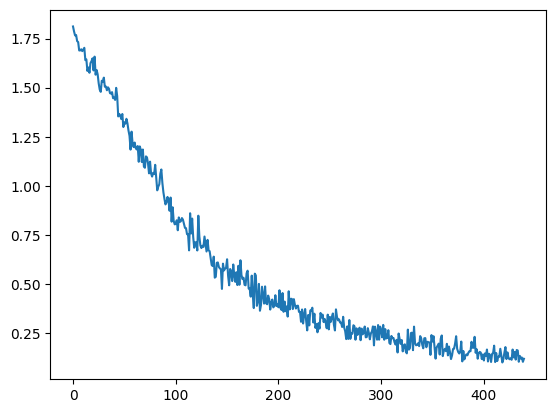

In [72]:
import matplotlib.pyplot as plt
plt.plot(train_losses)

### II.4 Initializing with pre-trained embeddings: 

Now, we would like to integrate pre-trained word embeddings into our model ! However, we need to not forget to add a vector for the padding symbol.

In [73]:
def get_glove_adapted_embeddings(glove_model, input_voc):
    keys = {i: glove_model.key_to_index.get(w, None) for w, i in input_voc.items()}
    index_dict = {i: key for i, key in keys.items() if key is not None}
    # Important change here: add one supplementary word for padding
    embeddings = np.zeros((len(input_voc)+1,glove_model.vectors.shape[1])) 
    for i, ind in index_dict.items():
        embeddings[i] = glove_model.vectors[ind]
    return embeddings

GloveEmbeddings = get_glove_adapted_embeddings(loaded_glove_model, training_word2idx)

In [74]:
print(GloveEmbeddings.shape)

(10002, 300)


Here, implement a ```PretrainedAveragingModel``` very similar to the previous model, using the ```nn.Embedding``` method ```from_pretrained()``` to initialize the embeddings from a numpy array. Use the ```requires_grad_``` method to specify if the model must fine-tune the embeddings or not ! 
<div class='alert alert-block alert-info'>
            Code:</div>

In [75]:
class PretrainedAveragingModel(nn.Module):
    def __init__(self, embedding_dim, num_classes, pretrained_embeddings, freeze_embeddings=True):
        super().__init__()
        vocab_size = pretrained_embeddings.shape[0]

        self.embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embeddings.weight = nn.Parameter(pretrained_embeddings)
        
        self.embeddings.weight.requires_grad = not freeze_embeddings

        self.linear = nn.Linear(embedding_dim, num_classes)

    def forward(self, inputs):
        embedded = self.embeddings(inputs)

        # Mask padding and compute mean
        mask = (inputs != 0).unsqueeze(-1).float()
        summed = torch.sum(embedded * mask, dim=1)
        counts = torch.sum(mask, dim=1)
        averaged = summed / counts.clamp(min=1e-5)

        return self.linear(averaged)

<div class='alert alert-block alert-warning'>
            Questions:</div>
            
- What are the results **with and without fine-tuning of embeddings imported from GloVe** ? Explain them.
- Look again at the confusion matrix these results in more details.

**Answer**: With fine-tuning, the model usually learns better and gives slightly higher accuracy because it adapts the word embeddings to our dataset. Without fine-tuning, the model still performs well since GloVe embeddings are already good, but it might not fit the specific task as well. So, fine-tuning helps, but it's not always a huge difference.

In [76]:
model_pre_trained = PretrainedAveragingModel(300, max(ng_train_labels)+1, torch.FloatTensor(GloveEmbeddings), True)
opt_pre_trained = torch.optim.Adam(model_pre_trained.parameters(), lr=0.0025, betas=(0.9, 0.999))

In [77]:
train_losses = experiment(model_pre_trained, opt_pre_trained, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 1.810207486152649; training acc = 21.0
Batch 20 : training loss = 1.548621416091919; training acc = 44.5
Batch 40 : training loss = 1.347322702407837; training acc = 64.5
Epoch 1 : Validation loss = 1.3319287909702822; Validation acc = 63.86363636363637
Epoch 2:
Batch 0 : training loss = 1.2961403131484985; training acc = 63.5
Batch 20 : training loss = 1.207116723060608; training acc = 67.0
Batch 40 : training loss = 1.1198301315307617; training acc = 68.0
Epoch 2 : Validation loss = 1.1257334351539612; Validation acc = 68.81818181818181
Epoch 3:
Batch 0 : training loss = 1.1156525611877441; training acc = 67.5
Batch 20 : training loss = 1.0258536338806152; training acc = 75.0
Batch 40 : training loss = 1.0878411531448364; training acc = 66.0
Epoch 3 : Validation loss = 1.0081936703486876; Validation acc = 71.5909090909091
Epoch 4:
Batch 0 : training loss = 1.0747052431106567; training acc = 65.0
Batch 20 : training loss = 0.962

In [78]:
model_pre_trained_light = PretrainedAveragingModel(300, max(ng_train_labels)+1, torch.FloatTensor(GloveEmbeddings), False)
opt_pre_trained_light = torch.optim.Adam(model_pre_trained_light.parameters(), lr=0.0025, betas=(0.9, 0.999))

In [79]:
train_losses = experiment(model_pre_trained_light, opt_pre_trained_light, criterion)

Beginning training...
Epoch 1:
Batch 0 : training loss = 1.8046870231628418; training acc = 17.0
Batch 20 : training loss = 1.4854522943496704; training acc = 51.5
Batch 40 : training loss = 1.2016280889511108; training acc = 70.0
Epoch 1 : Validation loss = 1.1513428769328378; Validation acc = 71.0
Epoch 2:
Batch 0 : training loss = 1.1050035953521729; training acc = 75.0
Batch 20 : training loss = 0.9679848551750183; training acc = 73.0
Batch 40 : training loss = 0.7976131439208984; training acc = 78.0
Epoch 2 : Validation loss = 0.7717167640274222; Validation acc = 78.54545454545455
Epoch 3:
Batch 0 : training loss = 0.6443328857421875; training acc = 83.5
Batch 20 : training loss = 0.5672033429145813; training acc = 83.5
Batch 40 : training loss = 0.5670301914215088; training acc = 79.0
Epoch 3 : Validation loss = 0.6167644770307974; Validation acc = 81.27272727272727
Epoch 4:
Batch 0 : training loss = 0.49524590373039246; training acc = 86.5
Batch 20 : training loss = 0.4068854451